<a href="https://colab.research.google.com/github/hadiritch-cell/Strogatz/blob/main/WS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Q2(b)

# read in data

# create graph object

# compute the clustering coefficient and diameter

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
edges = [
    (1,2),(2,3),(3,4),(4,5),(5,6),(6,7),(7,8),(8,1),
    (1,3),(3,5),(5,7),(7,1),
    (2,4),(4,6),(6,8),(8,2)
]

df_edges = pd.DataFrame(edges, columns=["source", "target"])
df_edges.to_csv("WS_edges.csv", index=False)
print("Edge list saved to WS_edges.csv")
print(df_edges)

df = pd.read_csv("WS_edges.csv")

G = nx.from_pandas_edgelist(df, source="source", target="target")

print("\n Graph properties")
print(f"Nodes : {sorted(G.nodes())}")
print(f"Edges : {G.number_of_edges()}")
print(f"Degree: { {n: d for n, d in G.degree()} }")

local_cc  = nx.clustering(G)
global_cc = nx.average_clustering(G)

print("\nClustering Coefficients")
for node in sorted(G.nodes()):
    print(f"  C({node}) = {local_cc[node]:.4f}")
print(f"\n  WS Clustering Coefficient (average) = {global_cc:.4f}")

Edge list saved to WS_edges.csv
    source  target
0        1       2
1        2       3
2        3       4
3        4       5
4        5       6
5        6       7
6        7       8
7        8       1
8        1       3
9        3       5
10       5       7
11       7       1
12       2       4
13       4       6
14       6       8
15       8       2

 Graph properties
Nodes : [1, 2, 3, 4, 5, 6, 7, 8]
Edges : 16
Degree: {1: 4, 2: 4, 3: 4, 4: 4, 5: 4, 6: 4, 7: 4, 8: 4}

Clustering Coefficients
  C(1) = 0.5000
  C(2) = 0.5000
  C(3) = 0.5000
  C(4) = 0.5000
  C(5) = 0.5000
  C(6) = 0.5000
  C(7) = 0.5000
  C(8) = 0.5000

  WS Clustering Coefficient (average) = 0.5000


In [ ]:
import pandas as pd
import networkx as nx

edges = [
    (1,2),(2,3),(3,4),(4,5),(5,6),(6,7),(7,8),(8,1),
    (1,3),(3,5),(5,7),(7,1),
    (2,4),(4,6),(6,8),(8,2)
]

df_edges = pd.DataFrame(edges, columns=["source", "target"])
df_edges.to_csv("WS_edges.csv", index=False)

df = pd.read_csv("WS_edges.csv")

G = nx.from_pandas_edgelist(df, source="source", target="target")

# ── 4. Compute Diameter ───────────────────────────────────────────────────────
diameter = nx.diameter(G)

print("\n── Shortest Path Lengths from Node 1 ────────────")
sp = dict(nx.single_source_shortest_path_length(G, source=1))
for target in sorted(sp):
    print(f"  1 → {target} : {sp[target]} hop(s)")

print(f"\n  Diameter = {diameter}")


── Shortest Path Lengths from Node 1 ────────────
  1 → 1 : 0 hop(s)
  1 → 2 : 1 hop(s)
  1 → 3 : 1 hop(s)
  1 → 4 : 2 hop(s)
  1 → 5 : 2 hop(s)
  1 → 6 : 2 hop(s)
  1 → 7 : 1 hop(s)
  1 → 8 : 1 hop(s)

  Diameter = 2


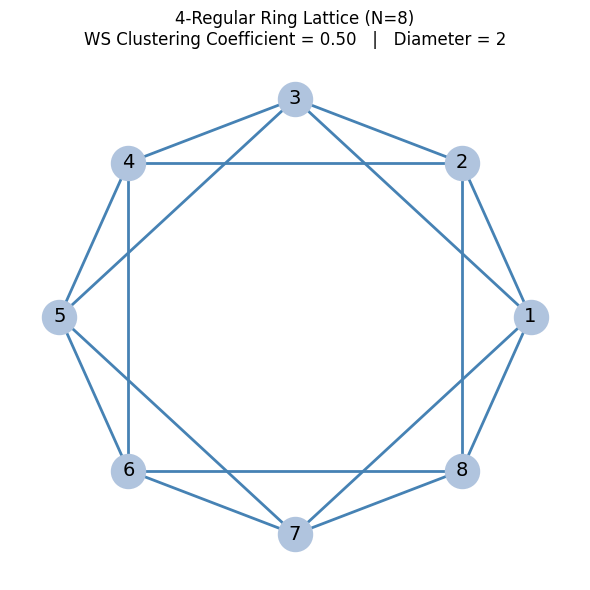

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

edges = [
    (1,2),(2,3),(3,4),(4,5),(5,6),(6,7),(7,8),(8,1),
    (1,3),(3,5),(5,7),(7,1),
    (2,4),(4,6),(6,8),(8,2)
]

df_edges = pd.DataFrame(edges, columns=["source", "target"])
df_edges.to_csv("WS_edges.csv", index=False)

df = pd.read_csv("WS_edges.csv")

G = nx.from_pandas_edgelist(df, source="source", target="target")

# Calculate clustering coefficient and diameter
global_cc = nx.average_clustering(G)
diameter = nx.diameter(G)

# ── 5. Visualise ──────────────────────────────────────────────────────────────
pos = nx.circular_layout(G)

plt.figure(figsize=(6,6))
nx.draw_networkx(G, pos,
                 node_color="lightsteelblue",
                 node_size=600,
                 font_size=14,
                 edge_color="steelblue",
                 width=2)
plt.title(f"4-Regular Ring Lattice (N=8)\n"
          f"WS Clustering Coefficient = {global_cc:.2f}   |   Diameter = {diameter}",
          fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.savefig("fig19_network.png", dpi=150)
plt.show()